In [1]:
import pandas as pd
import numpy as np
from pprint import pprint
from matplotlib import pyplot as plt

df = pd.read_json("books_dirty.json")

# Replace "" with np.nan
df = df.replace("", np.nan)


# For certain columns, we can force convert all values to numeric, or NaN if not possible. Final dtype will be float
cols = ["publication_year", "page_count", "average_rating", "ratings_count", "price_usd", "sales_millions"]
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Normalize dates in last_checkout
df["last_checkout"] = pd.to_datetime(df["last_checkout"], format="mixed", errors="coerce")

# Clamp publication year between 1800 and 2026
df = df[(df["publication_year"] >= 1800) & (df["publication_year"] <= 2026)]

# Ensure realistic values for page count
df = df[df["page_count"] > 0]

# Ensure realistic values for average_rating
df = df[(df["average_rating"] >= 0.0) & (df["average_rating"] <= 5.0)]

# Ensure realistic values ratings_count, price_usd and sales_million
df = df[
    (df["ratings_count"].fillna(0) >= 0) & 
    (df["price_usd"].fillna(0) >= 0) & 
    (df["sales_millions"].fillna(0) >= 0)
]
cols = ["genre", "language", "format", "publisher"]
df[cols] = df[cols].apply(lambda x: x.str.capitalize())

df = df.drop_duplicates(subset=["title", "author"])

# Doing this results in a zero records remaining in the dataset
# df = df.dropna()

print(df.size)

# df is now cleaned!





208


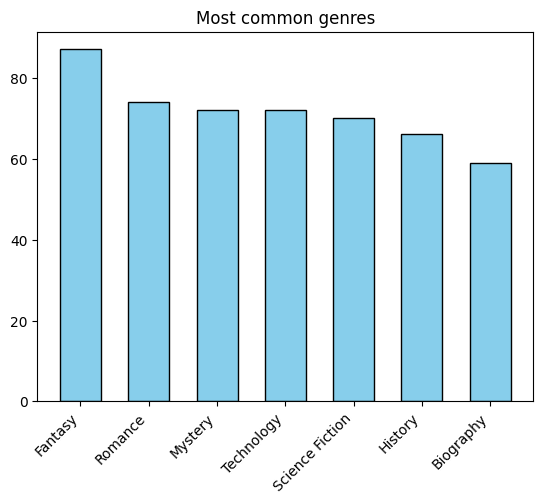

In [12]:
from matplotlib import pyplot as plt
df = pd.read_json("books_dirty.json")
#print(df.head(10))
genre_counts = df.groupby('genre').size().sort_values(ascending=False)
plt.bar(genre_counts.index, genre_counts.values, color='skyblue', edgecolor='black', width=0.6)
plt.xticks(rotation=45, ha='right')
plt.title("Most common genres")
plt.show()